In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/ELG/alltiles_ELGzinfo.fits'))
print(len(deep), len(np.unique(deep['TARGETID'])))

mask = deep['subset']=='deep'
print(np.sum(mask))
mask &= deep['TARGETS']=='ELG'
print(np.sum(mask))

deep = deep[mask]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 3000.
mask = deep['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

print(len(deep), len(np.unique(deep['TARGETID'])))

deep.rename_columns(['B_DEPTH', 'R_DEPTH', 'Z_DEPTH', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR'],
    ['B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep'])

179361 26051
27012
20382
20382 20382
FIBERSTATUS 16870 3512 0.17230890000981258
No data 16870 0 0.0
15081 1789 0.8939537640782454
15081 15081


## Select FDR ELGs

In [5]:
elg_sv = deep['SV1_DESI_TARGET'] & 2**1>0
elg_gtot = deep['SV1_DESI_TARGET'] & 2**10>0
elg_gfib = deep['SV1_DESI_TARGET'] & 2**11>0

deep = deep[elg_gtot]

In [6]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/ELG/alltiles_ELGzinfo_1exp.fits'))
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
mask &= np.in1d(zbest['TILEID'], np.unique(deep['TILEID']))
zbest = zbest[mask]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

zbest = join(zbest, deep[['TARGETID', 'B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep']], keys='TARGETID')

tileid_list = np.unique(zbest['TILEID'])

372447 26051
77590 5214


In [7]:
zbest[:1]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,DELTA_X,DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,elgqso_weight,FIELD,TARGETS,SPECMODEL_SKY_RMAG_AB,HASGFA,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,BITPSFFN,BITFRAMEFN,BITSKYFN,BITSFRAMEFN,BITFLUXCALIBFN,BITCFRAMEFN,TGT,SKY,STD,WD,LRG,ELG,QSO,BGS,MWS,TILERA,TILEDEC,EXPTIME,MJDOBS,GFA_AIRMASS,GFA_MOON_ILLUMINATION,GFA_MOON_ZD_DEG,GFA_MOON_SEP_DEG,GFA_TRANSPARENCY,GFA_FWHM_ASEC,GFA_SKY_MAG_AB,GFA_FIBER_FRACFLUX,GFA_FIBER_FRACFLUX_ELG,GFA_TRANSPFRAC,GFA_MAXCONTRAST,GFA_MINCONTRAST,GFA_KTERM,GFA_RADPROF_FWHM_ASEC,Z_deep,ZWARN_deep,DELTACHI2_deep,B_DEPTH_deep,R_DEPTH_deep,Z_DEPTH_deep,B_DEPTH_EBVAIR_deep,R_DEPTH_EBVAIR_deep,Z_DEPTH_EBVAIR_deep
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,float64,float64,float64,float64,float64,str10,str7,float32,bool,float32,float32,float32,float32,float32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,int64,float64,float64,float64,float64,float64,float64,float64
39627640553868904,9291.050867691636,149.18483041968554 .. 1.1323908765146895,1.4753666176608158,0.00015203111823524495,0,7843,GALAXY,,10,45.321022883057594,0,1,1,464,1464,524,0,35.746675241066676,-5.8999094331945825,0.0,0.0,2020.9487,5400.0,1374389536002,1,TGT,177.04205,-353.9224,0,3000,0.9570839083966932,3,DEV,1.0882385,1.5514032,3.8196244,310.81827,215.13818,19.531353,0,,0.0,0.0,0.0,0.0,0.026,10.238676,9.94459,0.15262029,0.21757694,0.5356842,0.15270323,0.21766777,0.535752,0,4.0,4.6535163,0.40477824,-0.105699725,S,1374389536002,0,0,3000,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,177.001,-353.857,0.008,-0.006,35.74664468278833,-5.899930673671516,20201216,68284,59200.14312098,80606,960.9117720127106,16964.7177734375,93.12626123428345,122.04262351989746,1.0,XMM-LSS,ELG,21.390554,True,1500.3,1129.5,976.4,1167.6627,967.3597,895.428,1073741823,1073741823,1073741823,1073741823,1073741823,1073741823,4198,800,136,10,8,4060,201,10,131,36.448,-4.501,900.0,59200.145,1.257425,0.08022895,100.23187,92.341225,1.050341,0.89041924,20.955372,0.6296618,0.4480651,0.6613596,9.916743,6.556842,0.114,0.9316542,1.4756226857979526,0,119.63786733150482,9100.300079345703,7745.799865722656,7717.0001220703125,7068.034027099609,6628.393005371094,7074.704650878906


In [8]:
t = Table()
_, idx = np.unique(zbest['TARGETID'], return_index=True)
t['TILEID'], t['count_unique'] = np.unique(zbest['TILEID'][idx], return_counts=True)
t1 = Table()
t1['TILEID'], t1['count_repeat'] = np.unique(zbest['TILEID'], return_counts=True)
t = join(t, t1)
t['ratio'] = t['count_repeat']/t['count_unique']
t

TILEID,count_unique,count_repeat,ratio
int32,int64,int64,float64
80606,1267,15108,11.92423046566693
80608,1154,30516,26.44367417677643
80610,1116,15428,13.824372759856631
80621,843,8369,9.927639383155398
80623,834,8169,9.79496402877698


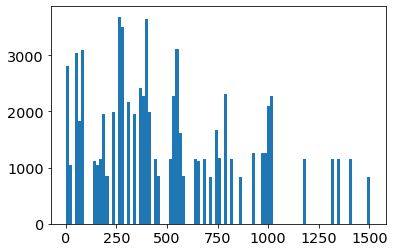

In [10]:
plt.hist(zbest['R_DEPTH_EBVAIR'], 100)
plt.show()

8172 1.0
4371


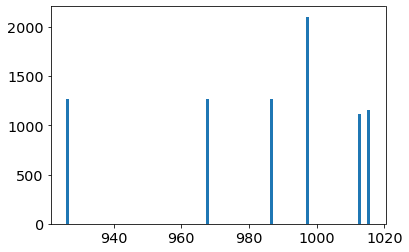

In [22]:
mask = (zbest['R_DEPTH_EBVAIR'] > 900) & (zbest['R_DEPTH_EBVAIR'] < 1100)
print(np.sum(mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(np.unique(zbest['TARGETID'])))

plt.hist(zbest['R_DEPTH_EBVAIR'], 100)
plt.show()

In [12]:
mask_zwarn = (zbest['ZWARN_deep']==0)

# Not repeatable
zdiff_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also include objects with ZWARN!=0 in the deep coadds
mask_fail |= (~mask_zwarn)
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

1926 0.2356828193832599
1969 0.24094468918257464


## Add FITBITS column

In [16]:
program = 'sv1'
target_class = 'ELG'

if program=='main':
    target_col = 'DESI_TARGET'
else:
    target_col = 'SV1_DESI_TARGET'

field = 'south'
tmp = fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_{}_{}_{}_0.49.0_basic.fits'.format(program, target_class.lower(), field), columns=['TARGETID'])
idx = np.where(np.in1d(tmp['TARGETID'], zbest['TARGETID']))[0]
print(len(idx))
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_{}_{}_{}_0.49.0_basic.fits'.format(program, target_class.lower(), field), columns=['RA', 'DEC', 'MASKBITS', 'TARGETID', target_col], rows=idx))
print('cat done')
cat1 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_{}_{}_{}_0.49.0_more_1.fits'.format(program, target_class.lower(), field), columns=['FITBITS'], rows=idx))
print('cat1 done')
cat = hstack([cat, cat1], join_type='exact')
print(len(cat))
cat_south = cat.copy()

field = 'north'
tmp = fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_{}_{}_{}_0.49.0_basic.fits'.format(program, target_class.lower(), field), columns=['TARGETID'])
idx = np.where(np.in1d(tmp['TARGETID'], zbest['TARGETID']))[0]
print(len(idx))
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_{}_{}_{}_0.49.0_basic.fits'.format(program, target_class.lower(), field), columns=['RA', 'DEC', 'MASKBITS', 'TARGETID', target_col], rows=idx))
print('cat done')
cat1 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/0.49.0/dr9_{}_{}_{}_0.49.0_more_1.fits'.format(program, target_class.lower(), field), columns=['FITBITS'], rows=idx))
print('cat1 done')
cat = hstack([cat, cat1], join_type='exact')
print(len(cat))
cat_north = cat.copy()

cat = vstack([cat_south, cat_north], join_type='exact')
print(len(cat))

2790
cat done
cat1 done
2790
1581
cat done
cat1 done
1581
4371


In [21]:
len(np.unique(zbest['TARGETID']))

4371

In [17]:
mask = np.in1d(cat['TARGETID'], zbest['TARGETID'])
print(np.sum(mask), np.sum(mask)-len(zbest), np.sum(mask)-len(cat))

4371 -3801 0


In [23]:
zbest = join(zbest, cat[['TARGETID', 'FITBITS']], keys='TARGETID')

In [26]:
iterative = zbest['FITBITS'] & 2**13 > 0
print(np.sum(iterative))
print(np.sum(iterative)/len(iterative))

217
0.026554087126774352


In [27]:
zbest_iter = zbest[iterative]
zbest_notiter = zbest[~iterative]

In [28]:
mask_zwarn = (zbest_iter['ZWARN_deep']==0)

# Not repeatable
zdiff_threshold = 0.0033
mask_fail = np.abs((zbest_iter['Z'] - zbest_iter['Z_deep'])/(1 + zbest_iter['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also include objects with ZWARN!=0 in the deep coadds
mask_fail |= (~mask_zwarn)
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

109 0.5023041474654378
111 0.511520737327189


In [29]:
mask_zwarn = (zbest_notiter['ZWARN_deep']==0)

# Not repeatable
zdiff_threshold = 0.0033
mask_fail = np.abs((zbest_notiter['Z'] - zbest_notiter['Z_deep'])/(1 + zbest_notiter['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also include objects with ZWARN!=0 in the deep coadds
mask_fail |= (~mask_zwarn)
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

1817 0.2284098051539912
1858 0.23356379635449404
